2026-01-17 01:25:14.849990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768613115.128127      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768613115.203037      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768613115.835337      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768613115.835409      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768613115.835412      17 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0

--- [1/6] GENERATE SPECTROGRAMS ---
Total data audio yang akan diproses: 773


100%|██████████| 773/773 [03:40<00:00,  3.50it/s]


Selesai! 773 spectrogram dibuat.
Membuat file ZIP (spectrograms.zip)...
ZIP selesai: /kaggle/working/spectrograms.zip

--- [2/6] DATA PREPARATION ---
Loading images to RAM...


100%|██████████| 773/773 [00:02<00:00, 314.92it/s]


Data Awal: Dry=522, Wet=96
Data Setelah Oversampling: Total 1044 (Balanced)

--- [3/6] TRAINING STAGE 1: MOBILENETV2 (FROZEN) ---


2026-01-17 01:29:17.072679: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 363ms/step - accuracy: 0.5258 - loss: 0.8610 - val_accuracy: 0.4452 - val_loss: 0.7957 - learning_rate: 0.0010
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - accuracy: 0.5872 - loss: 0.6907 - val_accuracy: 0.3355 - val_loss: 0.8662 - learning_rate: 0.0010
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.6425 - loss: 0.6227
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 0.6426 - loss: 0.6227 - val_accuracy: 0.4065 - val_loss: 0.8249 - learning_rate: 0.0010
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 300ms/step - accuracy: 0.6557 - loss: 0.6119 - val_accuracy: 0.4258 - val_loss: 0.8263 - learning_rate: 2.0000e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.6599 - loss: 0.5891
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.6598 - loss: 

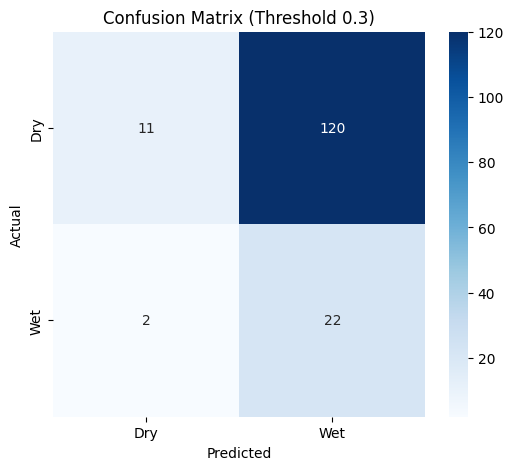

              precision    recall  f1-score   support

         Dry       0.85      0.08      0.15       131
         Wet       0.15      0.92      0.27        24

    accuracy                           0.21       155
   macro avg       0.50      0.50      0.21       155
weighted avg       0.74      0.21      0.17       155



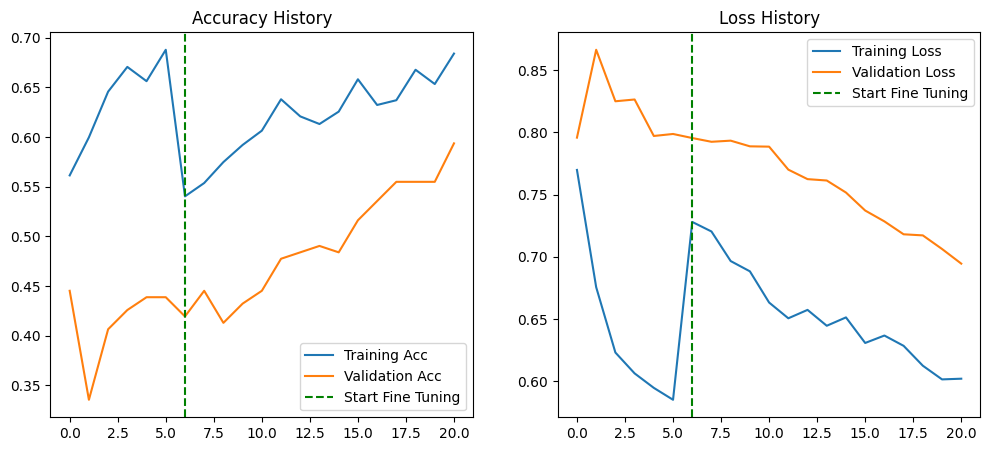

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# 1. KONFIGURASI
# ==========================================
INPUT_CSV = '/kaggle/input/metadata-compiled-csv/metadata_compiled.csv'
AUDIO_DIR_ROOT = '/kaggle/input/coughvid-wav/public_dataset/' # Sesuaikan path dataset audio Anda
OUTPUT_IMG_DIR = '/kaggle/working/processed_spectrograms'
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS_STAGE_1 = 20  # Permintaan user
EPOCHS_FINE_TUNE = 15 # Tambahan untuk fine tuning
MODEL_SAVE_NAME = 'final_cough_model.keras'

print(f"TensorFlow Version: {tf.__version__}")
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"File metadata tidak ditemukan di {INPUT_CSV}")

# ==========================================
# 2. PREPROCESSING (AUDIO -> SPECTROGRAM)
# ==========================================
print("\n--- [1/6] GENERATE SPECTROGRAMS ---")

# Buat folder output
if not os.path.exists(OUTPUT_IMG_DIR):
    os.makedirs(OUTPUT_IMG_DIR)

df = pd.read_csv(INPUT_CSV)
df = df[df['cough_type_4'].isin(['wet', 'dry'])] # Filter hanya wet & dry

print(f"Total data audio yang akan diproses: {len(df)}")

processed_count = 0
# Cek apakah folder kosong, jika ya, proses audio
if len(os.listdir(OUTPUT_IMG_DIR)) < 10: 
    for index, row in tqdm(df.iterrows(), total=df.shape[0]):
        uuid = row['uuid']
        
        # Cari file audio (support berbagai ekstensi)
        audio_path = None
        for ext in ['.wav', '.webm', '.ogg']:
            p = os.path.join(AUDIO_DIR_ROOT, uuid + ext)
            if os.path.exists(p):
                audio_path = p
                break
        
        if audio_path:
            try:
                # Load Audio
                y, sr = librosa.load(audio_path, sr=None)
                
                # Generate Mel-Spectrogram
                S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
                S_dB = librosa.power_to_db(S, ref=np.max)
                
                # Plot & Save (Tanpa Axis/Border agar bersih)
                plt.figure(figsize=(4, 4)) # Ukuran kecil cukup untuk CNN
                librosa.display.specshow(S_dB, sr=sr, fmax=8000)
                plt.axis('off') # Matikan axis
                
                save_path = os.path.join(OUTPUT_IMG_DIR, f"{uuid}.png")
                plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
                plt.close()
                processed_count += 1
            except Exception as e:
                pass # Skip error file
    print(f"Selesai! {processed_count} spectrogram dibuat.")
else:
    print("Spectrograms sudah ada, melewati proses generate...")

# Membuat file ZIP dari spectrogram (Sesuai request)
print("Membuat file ZIP (spectrograms.zip)...")
shutil.make_archive('/kaggle/working/spectrograms', 'zip', OUTPUT_IMG_DIR)
print("ZIP selesai: /kaggle/working/spectrograms.zip")



# ==========================================
# 3. DATA LOADING & OVERSAMPLING
# ==========================================
print("\n--- [2/6] DATA PREPARATION ---")

data = []
labels = []

# Load gambar kembali ke memori untuk training
# Kita gunakan os.listdir agar hanya meload gambar yang BERHASIL digenerate
valid_files = os.listdir(OUTPUT_IMG_DIR)
valid_uuids = [f.replace('.png', '') for f in valid_files]

# Filter DF agar sesuai dengan file yang ada
df_valid = df[df['uuid'].isin(valid_uuids)]

print("Loading images to RAM...")
for index, row in tqdm(df_valid.iterrows(), total=df_valid.shape[0]):
    uuid = row['uuid']
    label = 1 if row['cough_type_4'] == 'wet' else 0 # 1=Wet, 0=Dry
    img_path = os.path.join(OUTPUT_IMG_DIR, f"{uuid}.png")
    
    try:
        # Load RGB (MobileNet butuh 3 channel)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # Preprocessing MobileNet (Scaling -1 s/d 1)
        img = preprocess_input(img.astype(np.float32))
        
        data.append(img)
        labels.append(label)
    except:
        continue

X = np.array(data)
y = np.array(labels)

# Split Stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# OVERSAMPLING (Mengatasi data Wet yang sedikit)
X_wet = X_train[y_train == 1]
y_wet = y_train[y_train == 1]
X_dry = X_train[y_train == 0]
y_dry = y_train[y_train == 0]

print(f"Data Awal: Dry={len(X_dry)}, Wet={len(X_wet)}")

# Randomly sample Wet agar jumlahnya sama dengan Dry
if len(X_wet) > 0:
    ids = np.random.choice(np.arange(len(X_wet)), len(X_dry))
    X_wet_resampled = X_wet[ids]
    y_wet_resampled = y_wet[ids]

    # Gabung & Shuffle
    X_train_final = np.concatenate([X_dry, X_wet_resampled], axis=0)
    y_train_final = np.concatenate([y_dry, y_wet_resampled], axis=0)
    
    perm = np.random.permutation(len(X_train_final))
    X_train_final = X_train_final[perm]
    y_train_final = y_train_final[perm]
else:
    X_train_final, y_train_final = X_train, y_train

print(f"Data Setelah Oversampling: Total {len(X_train_final)} (Balanced)")

# DATA AUGMENTATION (Untuk mencegah Overfitting pada data duplikat)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ==========================================
# 4. STAGE 1: TRANSFER LEARNING (FROZEN)
# ==========================================
print("\n--- [3/6] TRAINING STAGE 1: MOBILENETV2 (FROZEN) ---")


# Download Base Model
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Bekukan

# Custom Head
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

# Train with Data Augmentation
history1 = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=BATCH_SIZE),
    epochs=EPOCHS_STAGE_1,
    validation_data=(X_test, y_test),
    callbacks=callbacks_stage1
)

# ==========================================
# 5. STAGE 2: FINE TUNING
# ==========================================
print("\n--- [4/6] TRAINING STAGE 2: FINE TUNING ---")


# Unfreeze Base Model
base_model.trainable = True

# Freeze layer bawah (low-level features), Unfreeze layer atas (high-level features)
# MobileNetV2 punya 155 layer. Kita latih mulai dari layer 100.
FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile dengan Learning Rate SANGAT KECIL (Penting!)
model.compile(optimizer=Adam(learning_rate=1e-5), # 0.00001
              loss='binary_crossentropy',
              metrics=['accuracy'])

callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(MODEL_SAVE_NAME, monitor='val_loss', save_best_only=True, mode='min') # Auto Save Best Model
]

history2 = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=BATCH_SIZE),
    epochs=EPOCHS_FINE_TUNE,
    validation_data=(X_test, y_test),
    callbacks=callbacks_finetune
)

# ==========================================
# 6. SAVING & EVALUATION
# ==========================================
print("\n--- [5/6] SAVING FINAL MODEL ---")
# Simpan eksplisit untuk memastikan
model.save('manual_final_save.keras') 
print(f"Model tersimpan sebagai: {MODEL_SAVE_NAME} (Best Checkpoint) dan manual_final_save.keras")

print("\n--- [6/6] EVALUASI AKHIR ---")
# Load model terbaik
final_model = load_model(MODEL_SAVE_NAME)

y_pred_prob = final_model.predict(X_test)

# Threshold Tuning (0.3 agar lebih sensitif mendeteksi Wet)
THRESHOLD = 0.3
y_pred = (y_pred_prob > THRESHOLD).astype("int32")

# Visualisasi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dry', 'Wet'], yticklabels=['Dry', 'Wet'])
plt.title(f'Confusion Matrix (Threshold {THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Dry', 'Wet'], zero_division=0))

# Plot History Gabungan
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Acc')
plt.plot(val_acc, label='Validation Acc')
plt.axvline(x=len(history1.history['accuracy']), color='green', linestyle='--', label='Start Fine Tuning')
plt.title('Accuracy History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history1.history['accuracy']), color='green', linestyle='--', label='Start Fine Tuning')
plt.title('Loss History')
plt.legend()
plt.show()

In [2]:
import numpy as np
import librosa
import librosa.display
import cv2
import tensorflow as tf
import os
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ==========================================
# 1. KONFIGURASI
# ==========================================
# Nama file model harus sesuai dengan yang disave terakhir
MODEL_PATH = 'final_cough_model.keras' 

# Threshold 0.6 (Sesuai hasil diagnosa agar tidak 'Wet' terus)
THRESHOLD = 0.6 

# Path Dataset
CSV_PATH = '/kaggle/input/metadata-compiled-csv/metadata_compiled.csv'
AUDIO_DIR = '/kaggle/input/coughvid-wav/public_dataset/'

# Cek Model Dulu
if not os.path.exists(MODEL_PATH):
    # Coba nama alternatif jika yang utama tidak ada
    if os.path.exists('manual_final_save.keras'):
        MODEL_PATH = 'manual_final_save.keras'
    else:
        raise FileNotFoundError("File model tidak ditemukan! Pastikan proses training sudah selesai.")

print(f"🤖 Memuat Model dari: {MODEL_PATH}")
final_model = tf.keras.models.load_model(MODEL_PATH)

# ==========================================
# 2. FUNGSI PREDIKSI
# ==========================================
def predict_audio_file(audio_path, true_label):
    try:
        # --- Preprocessing (Sama persis dengan Training) ---
        y, sr = librosa.load(audio_path, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        # Render Spectrogram ke Memory Buffer
        plt.figure(figsize=(4, 4))
        librosa.display.specshow(S_dB, sr=sr, fmax=8000)
        plt.axis('off')
        plt.tight_layout(pad=0)
        
        buf = BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        buf.seek(0)
        plt.close()
        
        # Convert Buffer ke Image Array
        file_bytes = np.asarray(bytearray(buf.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
        
        # Siapkan Input Model
        img_array = preprocess_input(img.astype(np.float32))
        img_array = np.expand_dims(img_array, axis=0)
        
        # --- Prediksi ---
        probabilitas = final_model.predict(img_array, verbose=0)[0][0]
        
        # --- Logika Keputusan ---
        is_wet = probabilitas > THRESHOLD
        pred_label = "WET" if is_wet else "DRY"
        
        # Pewarnaan Output
        color = "\033[91m" if is_wet else "\033[92m" # Merah jika Wet, Hijau jika Dry
        reset = "\033[0m"
        
        print(f"File: {os.path.basename(audio_path)}")
        print(f"Label Asli: {true_label} | Prediksi: {color}{pred_label}{reset} (Score: {probabilitas:.4f})")
        
        # Cek Benar/Salah
        match = (true_label.lower() == pred_label.lower())
        status = "✅ BENAR" if match else "❌ SALAH"
        print(f"Status: {status}\n{'-'*40}")
        
    except Exception as e:
        print(f"Error pada file {os.path.basename(audio_path)}: {e}")

# ==========================================
# 3. PENCARI FILE OTOMATIS & EKSEKUSI
# ==========================================
print("\n🔍 MENCARI SAMPEL AUDIO OTOMATIS...\n")

df = pd.read_csv(CSV_PATH)

# Fungsi helper untuk mencari file dengan berbagai ekstensi
def find_real_path(uuid):
    for ext in ['.wav', '.webm', '.ogg']:
        path = os.path.join(AUDIO_DIR, uuid + ext)
        if os.path.exists(path):
            return path
    return None

# Ambil 3 sampel Wet dan 3 sampel Dry secara acak
samples_wet = df[df['cough_type_4'] == 'wet'].sample(3, random_state=42)
samples_dry = df[df['cough_type_4'] == 'dry'].sample(3, random_state=42)

print("=== PENGUJIAN KASUS WET (BERDAHAK) ===")
for _, row in samples_wet.iterrows():
    path = find_real_path(row['uuid'])
    if path:
        predict_audio_file(path, "WET")
    else:
        print(f"File audio {row['uuid']} tidak ditemukan di dataset.")

print("\n=== PENGUJIAN KASUS DRY (KERING) ===")
for _, row in samples_dry.iterrows():
    path = find_real_path(row['uuid'])
    if path:
        predict_audio_file(path, "DRY")
    else:
        print(f"File audio {row['uuid']} tidak ditemukan di dataset.")

🤖 Memuat Model dari: final_cough_model.keras

🔍 MENCARI SAMPEL AUDIO OTOMATIS...

=== PENGUJIAN KASUS WET (BERDAHAK) ===
File: 336b15df-b282-4956-bb68-548ec950bb2f.wav
Label Asli: WET | Prediksi: WET (Score: 0.6920)
Status: ✅ BENAR
----------------------------------------
File: 380bc7f0-d950-450c-9f5e-43c7c3f4c132.wav
Label Asli: WET | Prediksi: WET (Score: 0.8087)
Status: ✅ BENAR
----------------------------------------
File: 08f05aa0-7c3d-40be-a8ae-ab6bc6d41be3.wav
Label Asli: WET | Prediksi: DRY (Score: 0.4308)
Status: ❌ SALAH
----------------------------------------

=== PENGUJIAN KASUS DRY (KERING) ===
File: 353bb06f-a51c-4646-b890-d7fd3529e0e2.wav
Label Asli: DRY | Prediksi: DRY (Score: 0.4092)
Status: ✅ BENAR
----------------------------------------
File: 7869b66e-5c53-42b8-8741-8e7398f78137.wav
Label Asli: DRY | Prediksi: DRY (Score: 0.3980)
Status: ✅ BENAR
----------------------------------------
File: 5c5888da-63a8-4357-acad-3b371173db46.wav
Label Asli: DRY | Prediksi: DRY (S

Menganalisis perilaku model...
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step


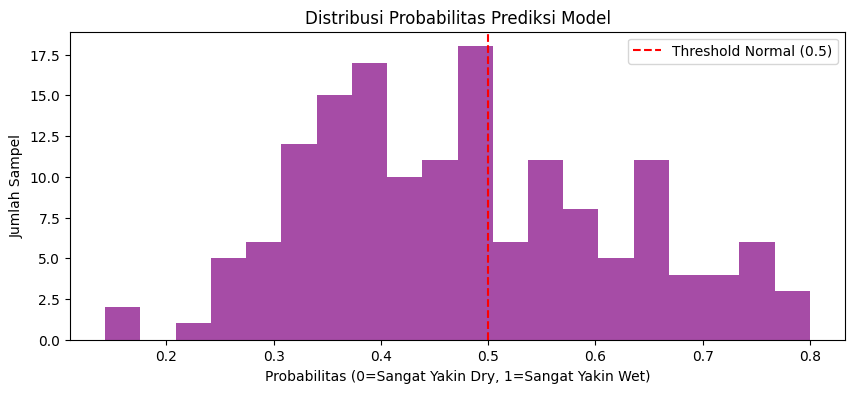


--- TEST BERBAGAI THRESHOLD ---
Threshold 0.5 -> Akurasi Dry: 61.1% | Deteksi Wet: 50.0%
Threshold 0.6 -> Akurasi Dry: 79.4% | Deteksi Wet: 25.0%
Threshold 0.7 -> Akurasi Dry: 92.4% | Deteksi Wet: 12.5%
Threshold 0.8 -> Akurasi Dry: 99.2% | Deteksi Wet: 0.0%

Rata-rata probabilitas output model: 0.4775
KESIMPULAN: Model Agresif. Dia mendeteksi Wet tapi tidak terlalu yakin.
SOLUSI: Gunakan Threshold tinggi (misal 0.7 atau 0.8) saat prediksi.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Model & Prediksi Ulang X_test
print("Menganalisis perilaku model...")
final_model = load_model('final_cough_model.keras') # Pastikan nama file sesuai
y_pred_raw = final_model.predict(X_test)

# 2. LIHAT HISTOGRAM PROBABILITAS (PENTING!)
# Ini akan memberitahu kita apakah model 'yakin' atau 'ragu-ragu'
plt.figure(figsize=(10, 4))
plt.hist(y_pred_raw, bins=20, color='purple', alpha=0.7)
plt.title('Distribusi Probabilitas Prediksi Model')
plt.xlabel('Probabilitas (0=Sangat Yakin Dry, 1=Sangat Yakin Wet)')
plt.ylabel('Jumlah Sampel')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold Normal (0.5)')
plt.legend()
plt.show()

# 3. CARI THRESHOLD TERBAIK
# Kita coba berbagai threshold untuk melihat mana yang paling masuk akal
print("\n--- TEST BERBAGAI THRESHOLD ---")
for thresh in [0.5, 0.6, 0.7, 0.8]:
    y_temp = (y_pred_raw > thresh).astype(int)
    # Hitung akurasi pada Wet saja (Recall) dan Dry saja (Specificity)
    cm = confusion_matrix(y_test, y_temp)
    
    # Handle jika cm tidak lengkap (misal model tebak 1 semua)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        recall_wet = tp / (tp + fn) if (tp+fn)>0 else 0
        acc_dry = tn / (tn + fp) if (tn+fp)>0 else 0
        print(f"Threshold {thresh} -> Akurasi Dry: {acc_dry*100:.1f}% | Deteksi Wet: {recall_wet*100:.1f}%")
    else:
        print(f"Threshold {thresh} -> Matrix tidak lengkap (Model bias parah)")

# 4. REKOMENDASI TINDAKAN
avg_pred = np.mean(y_pred_raw)
print(f"\nRata-rata probabilitas output model: {avg_pred:.4f}")

if avg_pred > 0.8:
    print("KESIMPULAN: Model 'Halu' (Overfitting). Dia menghafal data Wet.")
    print("SOLUSI: Ulangi training, kurangi epoch Fine-Tuning jadi 5 saja, atau perbesar 'rotation_range' pada augmentasi.")
elif avg_pred > 0.4:
    print("KESIMPULAN: Model Agresif. Dia mendeteksi Wet tapi tidak terlalu yakin.")
    print("SOLUSI: Gunakan Threshold tinggi (misal 0.7 atau 0.8) saat prediksi.")
else:
    print("KESIMPULAN: Distribusi normal.")
    